# Multi-Factor Equity Screener - demo

Runs **fully offline** on a synthetic universe with planted factor efficacy.

Pipeline: raw value/quality/momentum -> winsorize 1/99 per date -> sector-neutral z-scores -> lagged-IC-weighted composite -> quintile spread.

In [1]:
%pip install numpy>=1.26 pandas>=2.0 scipy>=1.11 matplotlib>=3.8 pytest>=8.0 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\pilat\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# ==== USER INPUTS ====
N_FIRMS = 200
N_PERIODS = 24
WINSOR = (0.01, 0.99)
N_QUANTILES = 5
SEED = 42
# =====================

In [3]:
import sys
sys.path.insert(0, "../src")
from data_loader import load_universe
from factors import compute_raw_factors, factor_correlations
from standardize import winsorize_cross_section, sector_neutral_zscore

panel = load_universe(n_firms=N_FIRMS, n_periods=N_PERIODS, seed=SEED)
raw = compute_raw_factors(panel)
z = sector_neutral_zscore(winsorize_cross_section(raw, *WINSOR), panel["sector"])
z.describe().round(2)

,value,quality,momentum
count,4800.00,4800.00,4800.00
mean,-0.00,-0.00,0.00
std,0.98,0.98,0.98
min,-2.11,-2.89,-2.92
25%,-0.71,-0.67,-0.67
50%,-0.15,0.02,-0.00
75%,0.51,0.68,0.66
max,3.78,2.76,2.85


## 1. Factor correlations - are the three factors actually distinct?

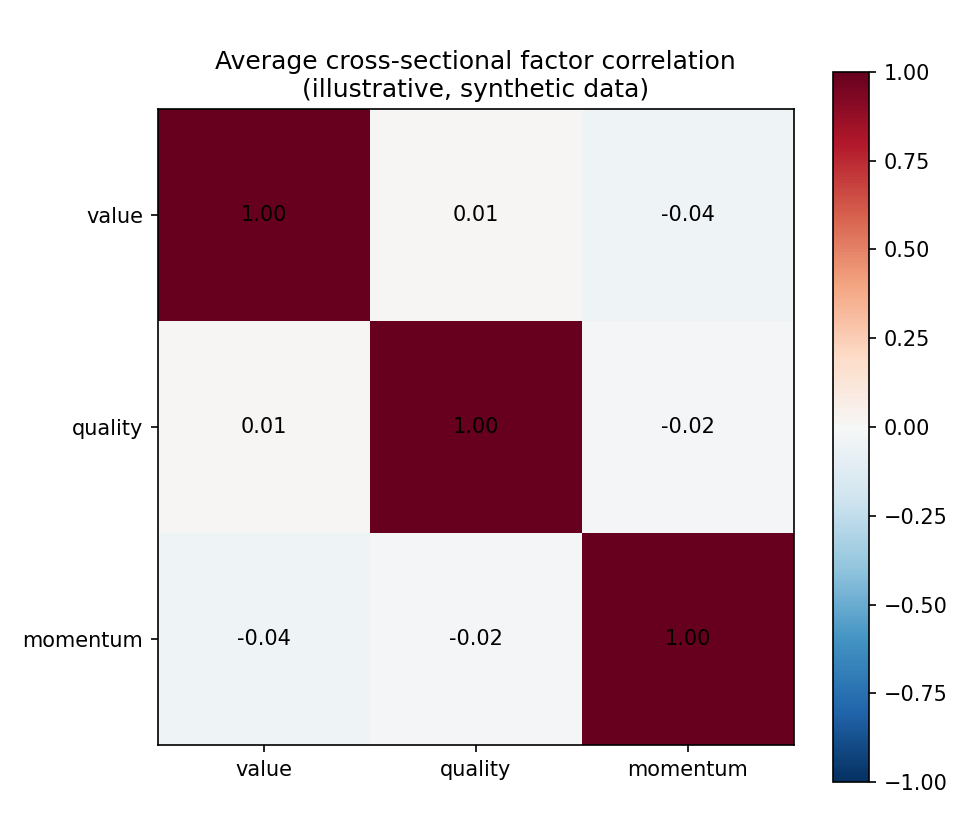

In [4]:
from plots import plot_factor_correlation
from IPython.display import Image, display
display(Image(str(plot_factor_correlation(factor_correlations(z)))))

## 2. ICs and no-look-ahead IC weighting

Mean ICs: {'value': 0.076, 'quality': 0.031, 'momentum': 0.023}


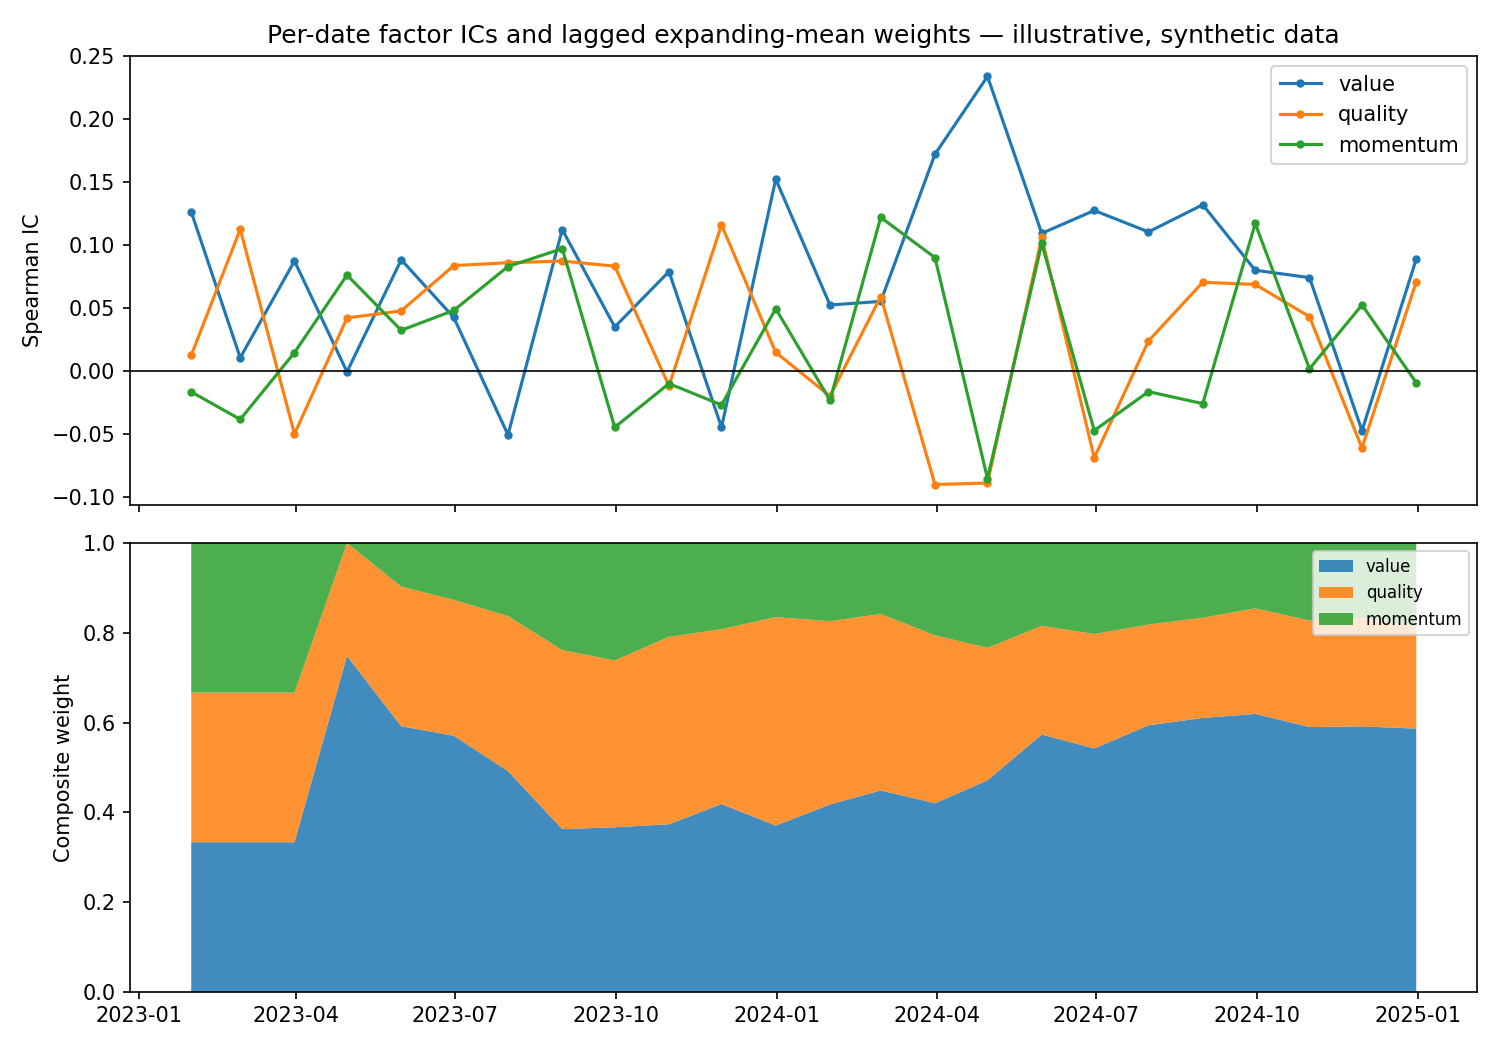

In [5]:
from composite import information_coefficients, ic_weights, composite_score, quintile_returns
from plots import plot_ic_series

ic_ts = information_coefficients(z, panel["fwd_return"])
weights = ic_weights(ic_ts)
print("Mean ICs:", ic_ts.mean().round(3).to_dict())
display(Image(str(plot_ic_series(ic_ts, weights))))

## 3. Composite quintile spread

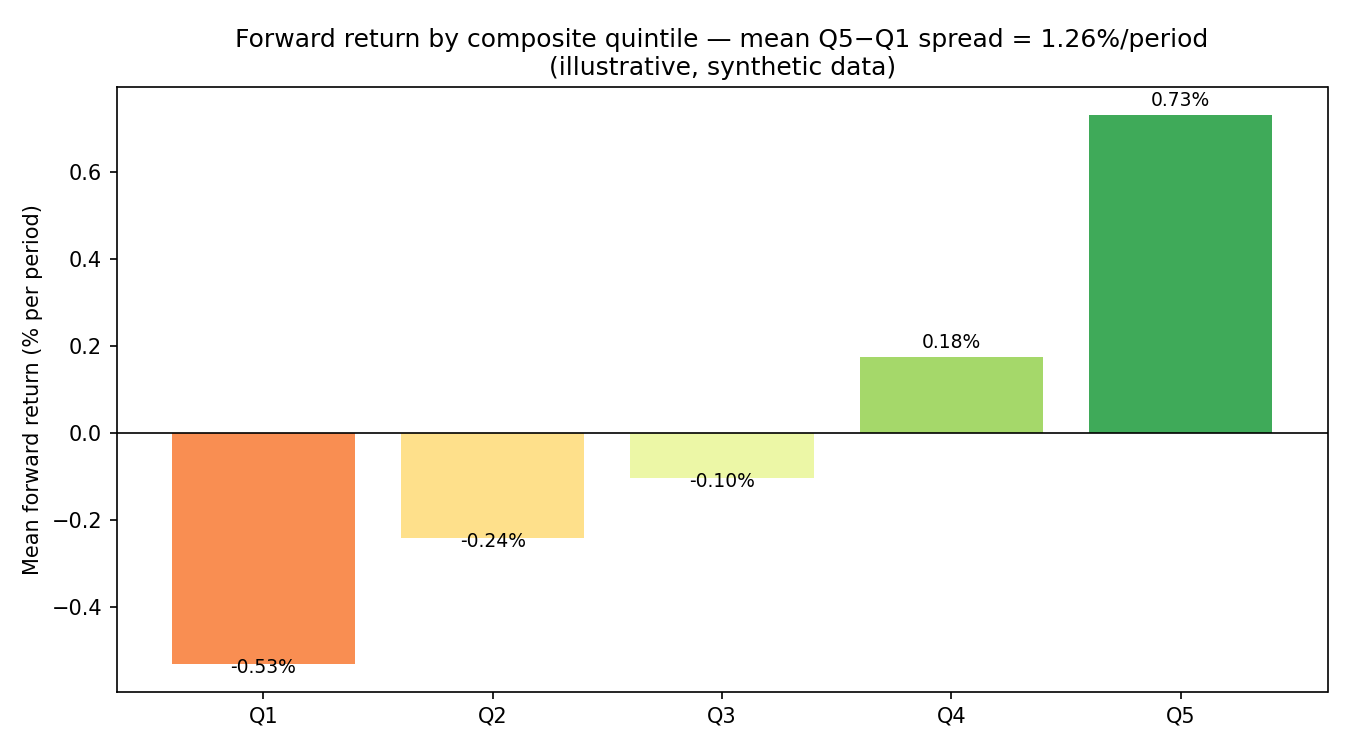

Mean Q5-Q1 spread: 1.265%/period (t = 6.48)


In [6]:
from plots import plot_quintile_spread

comp = composite_score(z, weights)
q_ret = quintile_returns(comp, panel["fwd_return"], N_QUANTILES)
display(Image(str(plot_quintile_spread(q_ret))))
print(f"Mean Q5-Q1 spread: {q_ret['spread'].mean():.3%}/period (t = {q_ret['spread'].mean()/q_ret['spread'].sem():.2f})")